# AI-Generated Text Detection (Exploratory Data Analysis)

This dataset contains 600 text documents (fiction, news, essays) labelled as
**human-written** or **AI-generated (GPT-4.1)**, with a subset of AI texts
additionally *obfuscated* to mimic human writing style.

The goal of this notebook is to understand the structure of the dataset, surface
distributional patterns, and visualise features that might distinguish the three
conditions: `human`, `ai_plain`, and `ai_obfuscated`.


## 1:  Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import string

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
PALETTE = {"human": "#4C9BE8", "ai_plain": "#E07B54", "ai_obfuscated": "#6ABF85"}
LABEL_PALETTE = {0: "#4C9BE8", 1: "#E07B54"}

DATA_PATH = "dataset_600.csv"


## 2:  Load & Inspect


In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(3)


Shape: (600, 9)


,doc_id,source_idx,genre,model,text,label,obfuscated,condition,technique
0,doc_0000,1116,fiction,human,"BASTARD. I know not why, except to get the lan...",0,False,human,NaN
1,doc_0001,1368,fiction,human,"I am a king, and privileged to speak. CLIFFORD...",0,False,human,NaN
2,doc_0002,422,fiction,human,"TITUS. Why, didst thou not come from heaven? C...",0,False,human,NaN


In [ ]:
df.dtypes


doc_id        object
source_idx     int64
genre         object
model         object
text          object
label          int64
obfuscated      bool
condition     object
technique     object
dtype: object

In [ ]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "  None")


Missing values per column:
technique    400
dtype: int64


**Notes:** `technique` is `NaN` for the 400 non-obfuscated documents,
it only applies to the `ai_obfuscated` condition, so the nulls are structurally
expected, not data quality issues.


## 3:  Clean & Prepare

In [ ]:
df["technique"] = df["technique"].fillna("none")

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows. Remaining: {len(df)}")

#Text features 
def avg_word_len(text):
    words = text.split()
    return np.mean([len(w.strip(string.punctuation)) for w in words if w.strip(string.punctuation)]) if words else 0

def punct_density(text):
    return sum(1 for c in text if c in string.punctuation) / max(len(text), 1)

def sentence_count(text):
    return len(re.findall(r'[.!?]+', text))

df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["sent_count"] = df["text"].apply(sentence_count)
df["avg_word_len"] = df["text"].apply(avg_word_len)
df["punct_density"] = df["text"].apply(punct_density)
df["avg_sent_len"] = df["word_count"] / df["sent_count"].replace(0, np.nan)
df["unique_word_ratio"] = df["text"].apply(
    lambda t: len(set(t.lower().split())) / max(len(t.split()), 1)
)

df[["condition","char_count","word_count","sent_count","avg_word_len",
    "punct_density","avg_sent_len","unique_word_ratio"]].groupby("condition").mean().round(3)


Dropped 0 exact duplicate rows. Remaining: 600
Feature engineering complete.


,char_count,word_count,sent_count,avg_word_len,punct_density,avg_sent_len,unique_word_ratio
condition,,,,,,,
ai_obfuscated,2948.610,512.315,44.585,4.614,0.030,12.153,0.590
ai_plain,3226.275,526.685,32.755,5.120,0.024,24.054,0.614
human,3871.610,658.520,43.245,4.750,0.030,18.516,0.537


## 4:  Descriptive Statistics

### 4.1:  Target & condition breakdown


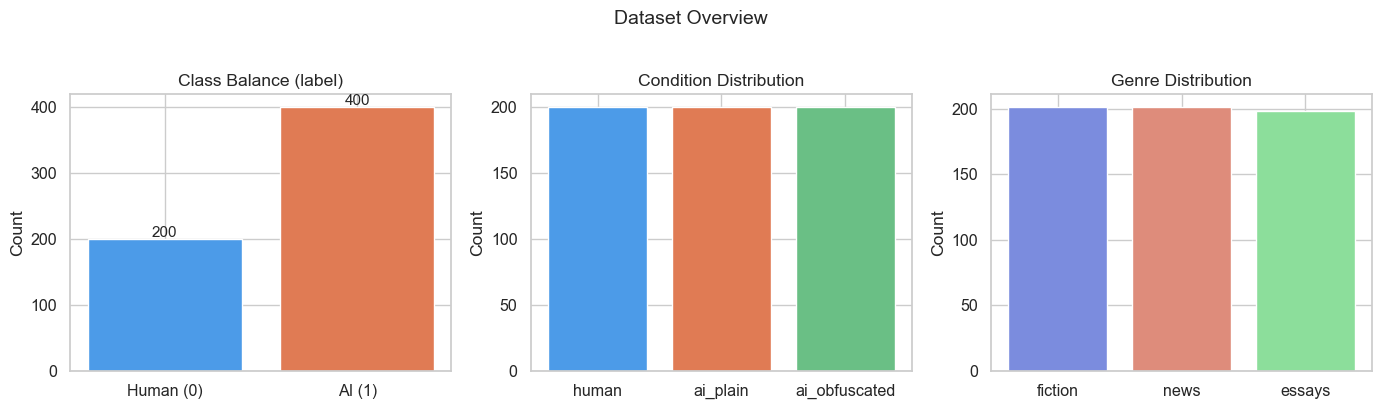

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Class balance
label_counts = df["label"].value_counts().sort_index()
axes[0].bar(["Human (0)", "AI (1)"], label_counts.values,
            color=[LABEL_PALETTE[0], LABEL_PALETTE[1]], edgecolor="white")
axes[0].set_title("Class Balance (label)")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontsize=11)

# Condition
cond_counts = df["condition"].value_counts()
axes[1].bar(cond_counts.index, cond_counts.values,
            color=[PALETTE[c] for c in cond_counts.index], edgecolor="white")
axes[1].set_title("Condition Distribution")
axes[1].set_ylabel("Count")

# Genre
genre_counts = df["genre"].value_counts()
axes[2].bar(genre_counts.index, genre_counts.values,
            color=["#7B8CDE", "#DE8C7B", "#8CDE9B"], edgecolor="white")
axes[2].set_title("Genre Distribution")
axes[2].set_ylabel("Count")

plt.suptitle("Dataset Overview", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Notes:**
There is an imbalance between the AI-generated (400) and the human texts (200). Additionally, all AI docs come from GPT-4.1, thus obfuscation techniques vary by genre

### 4.2:  Numeric summary by condition

In [7]:
summary = df.groupby("condition")[
    ["char_count","word_count","sent_count","avg_word_len",
     "punct_density","avg_sent_len","unique_word_ratio"]
].agg(["mean","median","std"]).round(3)
summary


char_count                   word_count                  \
                    mean  median       std       mean median      std   
condition                                                               
ai_obfuscated   2948.610  3360.5  1485.659    512.315  587.0  257.682   
ai_plain        3226.275  3852.5  1513.323    526.685  658.5  258.024   
human           3871.610  3906.0  3435.920    658.520  649.0  567.495   

              sent_count                avg_word_len  ...         \
                    mean median     std         mean  ...    std   
condition                                             ...          
ai_obfuscated     44.585   41.5  26.276        4.614  ...  0.306   
ai_plain          32.755   22.0  26.929        5.120  ...  0.549   
human             43.245   26.0  38.432        4.750  ...  0.405   

              punct_density               avg_sent_len                  \
                       mean median    std         mean  median     std   
condition                                                                
ai_obfuscated         0.030  0.029  0.008       12.153  11.422   3.565   
ai_plain              0.024  0.021  0.009       24.054  20.448  27.578   
human                 0.030  0.029  0.010       18.516  19.063   6.826   

              unique_word_ratio                
                           mean median    std  
condition                                      
ai_obfuscated             0.590  0.561  0.108  
ai_plain                  0.614  0.596  0.072  
human                     0.537  0.537  0.063  

[3 rows x 21 columns]

## 5:  Feature Distributions

### 5.1:  Text length by condition


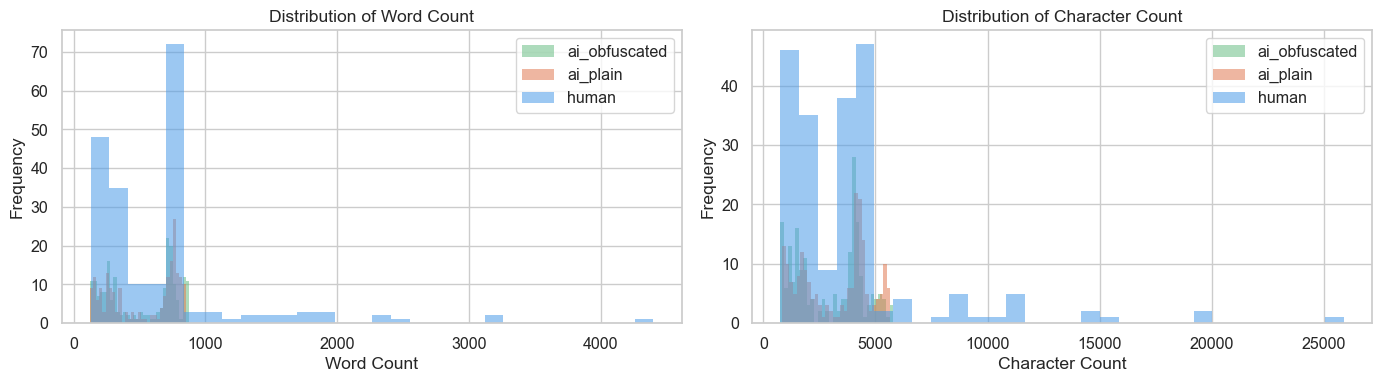

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in zip(axes,
                           ["word_count", "char_count"],
                           ["Word Count", "Character Count"]):
    for cond, grp in df.groupby("condition"):
        ax.hist(grp[col], bins=30, alpha=0.55, label=cond,
                color=PALETTE[cond], edgecolor="none")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {label}")
    ax.legend()

plt.tight_layout()
plt.show()


Human texts show a long right tail, a few very long documents pull the mean
up, while AI texts (both plain and obfuscated) are tightly clustered. This
suggests GPT-4.1 generates outputs within a consistent length range.


### 5.2:  Linguistic feature distributions

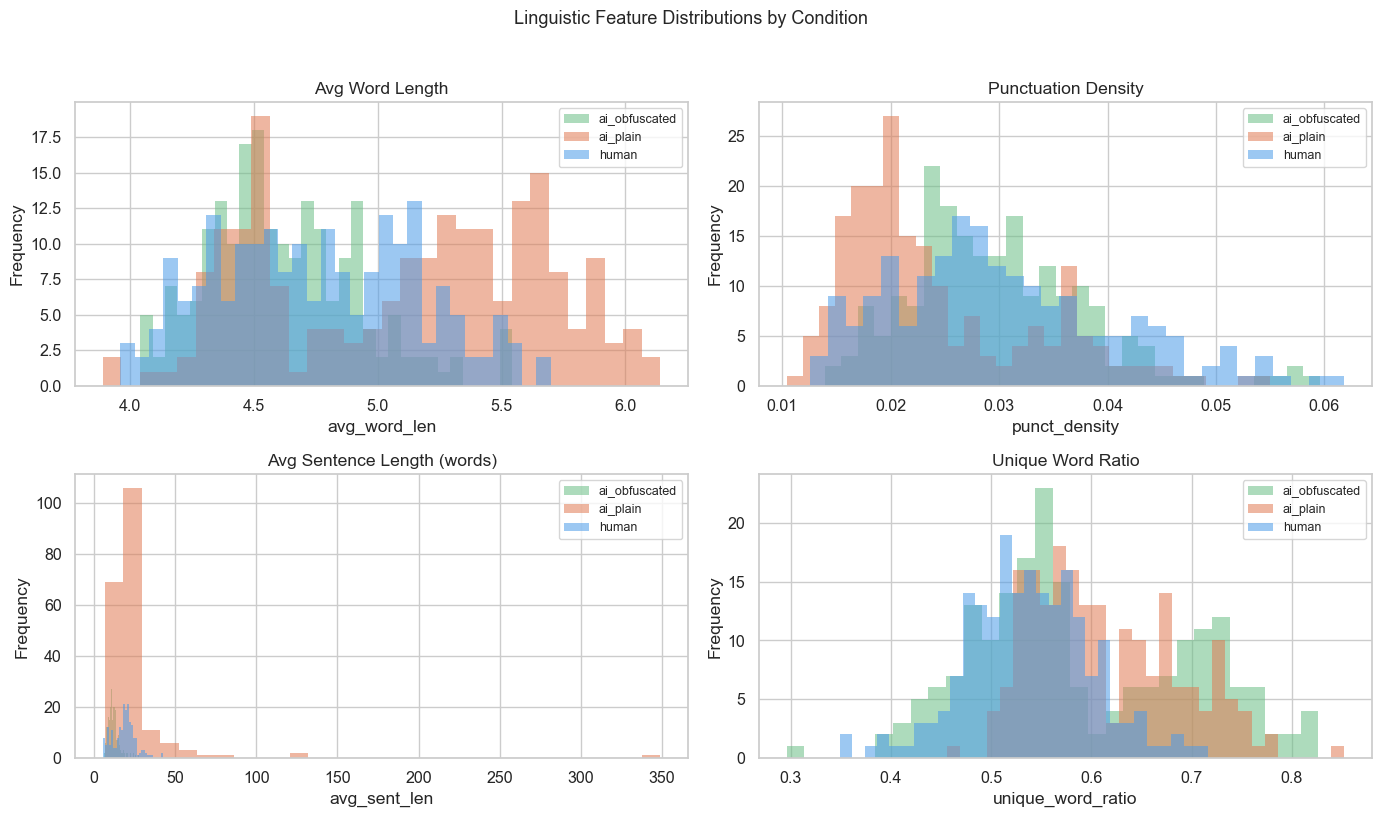

In [9]:
features = ["avg_word_len", "punct_density", "avg_sent_len", "unique_word_ratio"]
titles   = ["Avg Word Length", "Punctuation Density",
            "Avg Sentence Length (words)", "Unique Word Ratio"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, feat, title in zip(axes.flat, features, titles):
    for cond, grp in df.groupby("condition"):
        ax.hist(grp[feat].dropna(), bins=30, alpha=0.55,
                label=cond, color=PALETTE[cond], edgecolor="none")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle("Linguistic Feature Distributions by Condition", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 6:  Condition Comparison — Box Plots


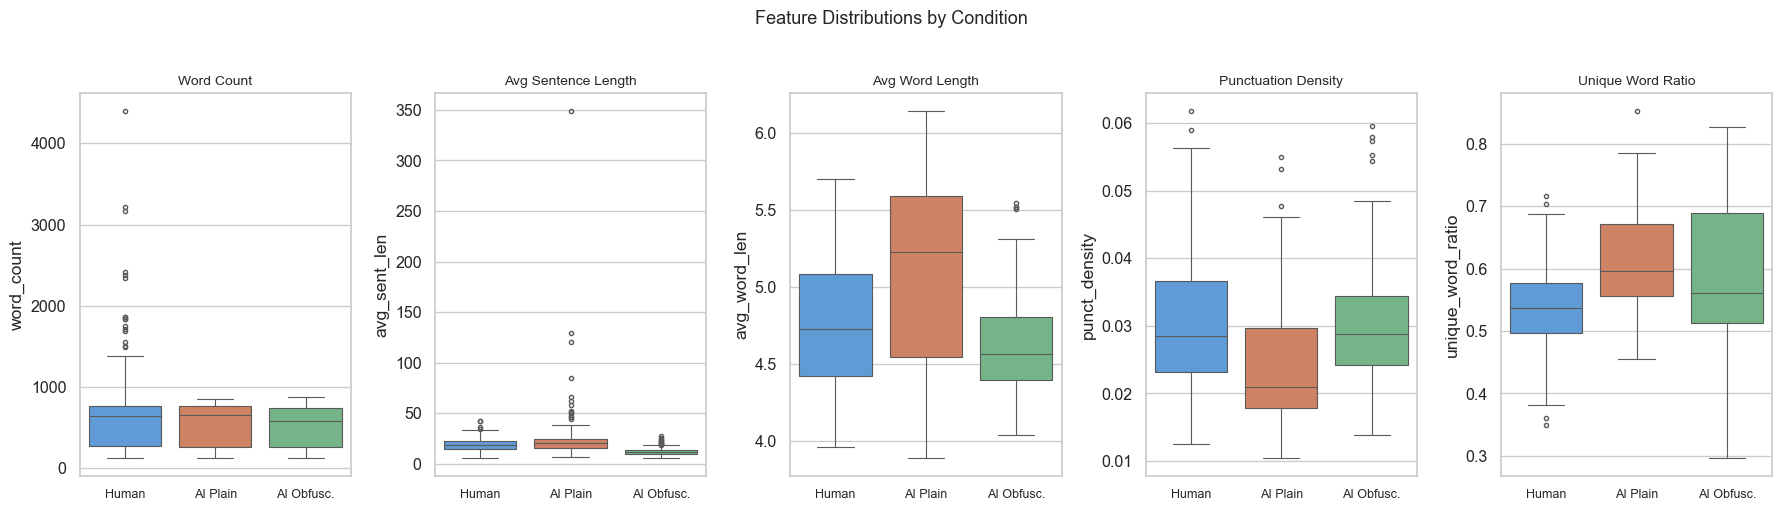

In [10]:
features_box = ["word_count", "avg_sent_len", "avg_word_len",
                "punct_density", "unique_word_ratio"]
titles_box   = ["Word Count", "Avg Sentence Length",
                "Avg Word Length", "Punctuation Density", "Unique Word Ratio"]

fig, axes = plt.subplots(1, len(features_box), figsize=(18, 5))

order = ["human", "ai_plain", "ai_obfuscated"]
for ax, feat, title in zip(axes, features_box, titles_box):
    sns.boxplot(data=df, x="condition", y=feat, order=order,
                palette=PALETTE, ax=ax, linewidth=0.8, fliersize=3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(["Human", "AI Plain", "AI Obfusc."], fontsize=9)

plt.suptitle("Feature Distributions by Condition", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Notes:**
- `ai_plain` texts tend to have longer sentences than both human and obfuscated texts
- Obfuscation reduces sentence length and word length, nudging the distribution
  closer to human writing, the technique is working as intended
- Human texts have far higher variance in word count (some very long documents)
- `unique_word_ratio` is similar across conditions, suggesting vocabulary richness
  alone is not a strong discriminator


## 7:  Genre × Condition Heatmap


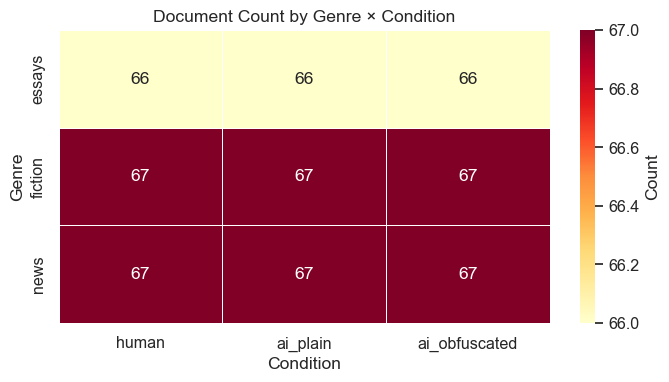

In [11]:
pivot = df.groupby(["genre", "condition"]).size().unstack(fill_value=0)
pivot = pivot[["human", "ai_plain", "ai_obfuscated"]]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Document Count by Genre × Condition")
ax.set_xlabel("Condition")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.show()


The dataset is well-balanced across genre × condition cells (67 documents each),
making cross-genre comparisons fair.


## 8:  Feature Correlation Matrix


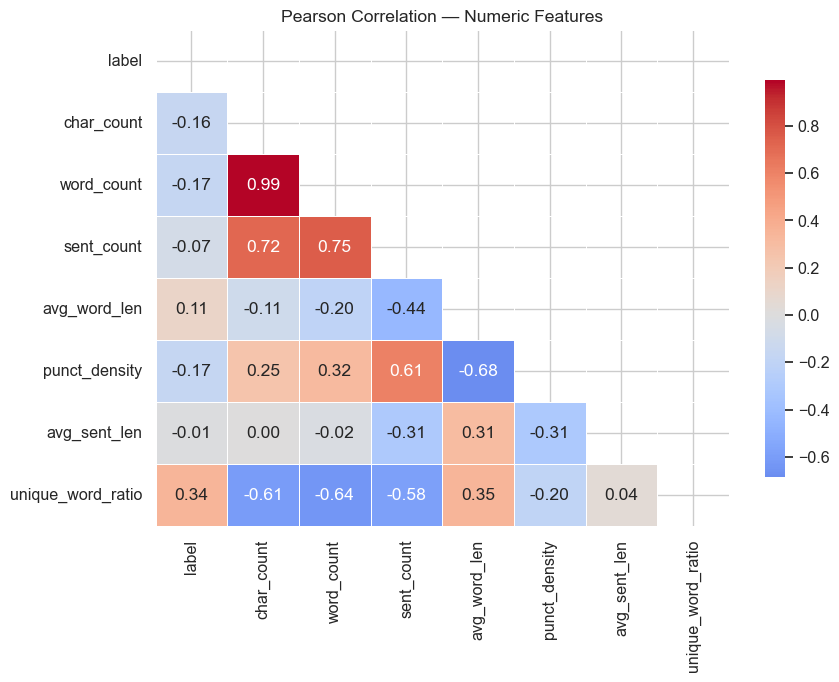

In [12]:
num_cols = ["label","char_count","word_count","sent_count",
            "avg_word_len","punct_density","avg_sent_len","unique_word_ratio"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation — Numeric Features")
plt.tight_layout()
plt.show()


**Notable correlations with `label` (0=human, 1=AI):**
- `char_count` and `word_count` are **negatively correlated** with the AI label: 
  AI texts in this dataset are slightly shorter on average
- `avg_sent_len` shows a mild **positive** correlation: AI tends toward longer sentences
- `unique_word_ratio` is weakly correlated, confirming it is not a strong signal


## 9:  Effect of Obfuscation on Linguistic Features


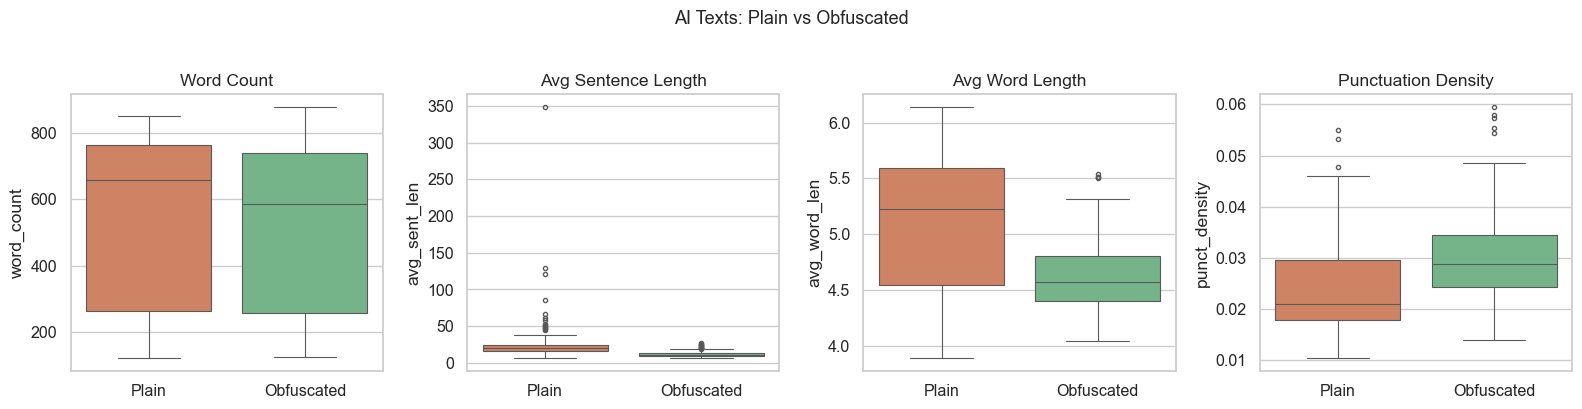

In [13]:
ai_df = df[df["label"] == 1].copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
feats = ["word_count","avg_sent_len","avg_word_len","punct_density"]
labs  = ["Word Count","Avg Sentence Length","Avg Word Length","Punctuation Density"]

for ax, feat, lab in zip(axes, feats, labs):
    sns.boxplot(data=ai_df, x="obfuscated", y=feat,
                palette={"False": PALETTE["ai_plain"], "True": PALETTE["ai_obfuscated"]},
                ax=ax, linewidth=0.8, fliersize=3)
    ax.set_xticklabels(["Plain", "Obfuscated"])
    ax.set_title(lab)
    ax.set_xlabel("")

plt.suptitle("AI Texts: Plain vs Obfuscated", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Obfuscation measurably **shortens sentences** and **reduces word length**,
which are the two surface signals most associated with AI writing style.
Punctuation density is largely unchanged, suggesting obfuscation techniques
focus on syntactic simplification rather than punctuation patterns.


## 10:  Obfuscation Techniques by Genre


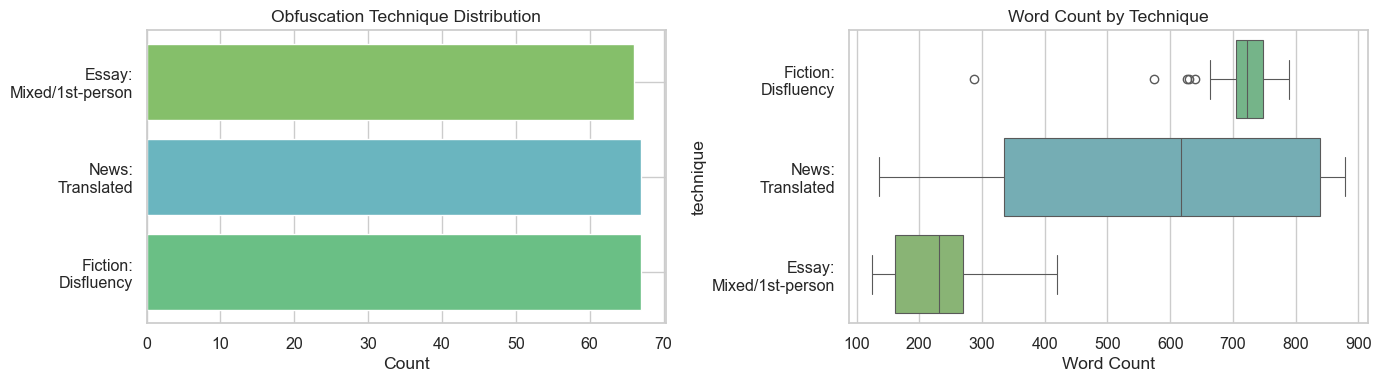

In [14]:
tech_df = df[df["technique"] != "none"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Technique counts
tc = tech_df["technique"].value_counts()
short_names = {
    "fiction_disfluency_humanized": "Fiction:\nDisfluency",
    "translated_news_awkward_plain": "News:\nTranslated",
    "essay_mixed_lengths_first_person": "Essay:\nMixed/1st-person"
}
axes[0].barh([short_names.get(t, t) for t in tc.index], tc.values,
             color=["#6ABF85","#6AB5BF","#85BF6A"])
axes[0].set_xlabel("Count")
axes[0].set_title("Obfuscation Technique Distribution")

# Word count by technique
sns.boxplot(data=tech_df, y="technique", x="word_count",
            order=tc.index,
            palette=["#6ABF85","#6AB5BF","#85BF6A"],
            ax=axes[1], linewidth=0.8)
axes[1].set_yticklabels([short_names.get(t, t) for t in tc.index])
axes[1].set_xlabel("Word Count")
axes[1].set_title("Word Count by Technique")

plt.tight_layout()
plt.show()


Each obfuscation technique is genre-specific:
- **Fiction (disfluency humanized)**: introduces hesitations and informal markers
- **News — translated awkward plain**: simulates back-translation artifacts
- **Essay — mixed lengths / first person**: varies sentence rhythm and adds first-person voice

All three techniques produce broadly similar length distributions, keeping
text length from being a confound in technique-specific studies.


## 11:  Word Count Density: All Three Conditions


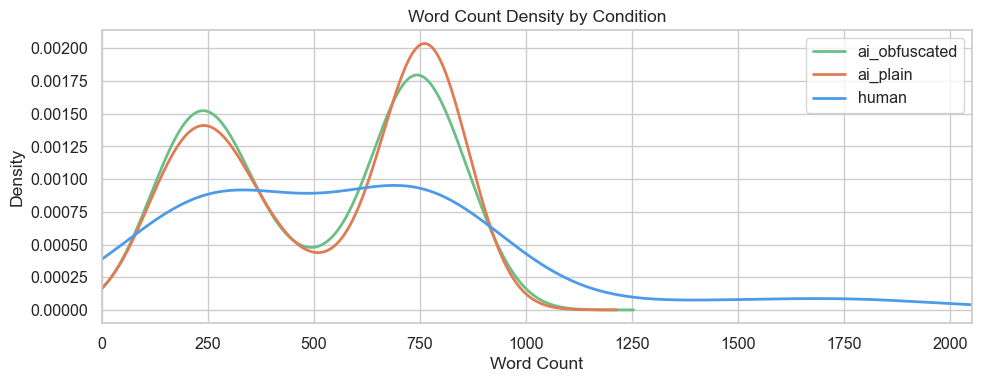

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

for cond, grp in df.groupby("condition"):
    grp["word_count"].plot.kde(ax=ax, label=cond, color=PALETTE[cond], linewidth=2)

ax.set_xlabel("Word Count")
ax.set_ylabel("Density")
ax.set_title("Word Count Density by Condition")
ax.set_xlim(0, df["word_count"].quantile(0.99) * 1.1)
ax.legend()
plt.tight_layout()
plt.show()


## 12:  Per-Genre Feature Profiles (Radar-style Bar Chart)


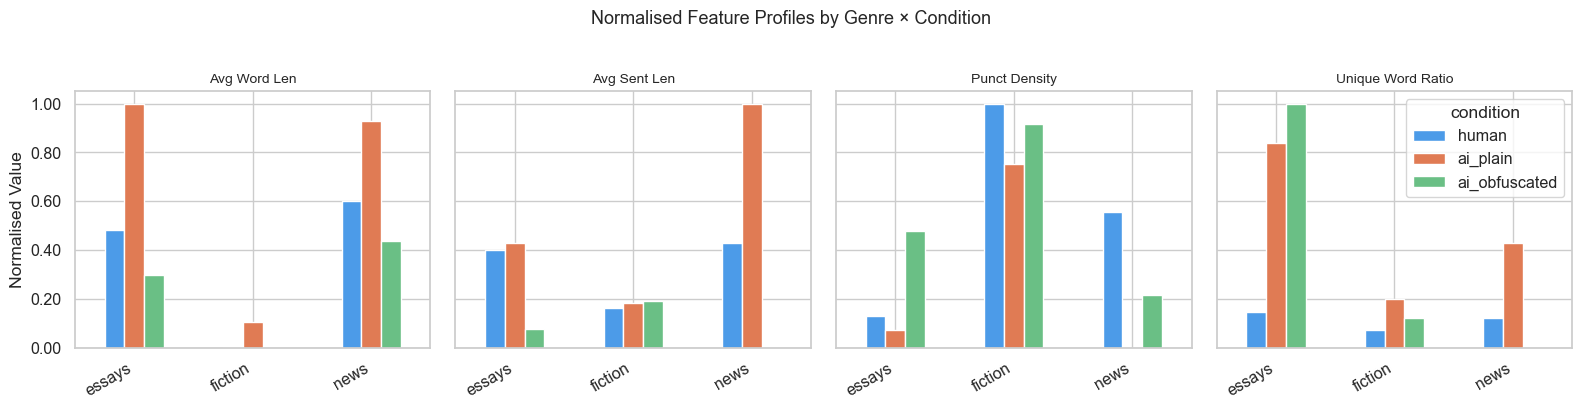

In [16]:
norm_feats = ["avg_word_len","avg_sent_len","punct_density","unique_word_ratio"]

genre_means = df.groupby(["genre","condition"])[norm_feats].mean()
# Min-max normalise within each feature
genre_norm = (genre_means - genre_means.min()) / (genre_means.max() - genre_means.min() + 1e-9)

genre_norm = genre_norm.reset_index()

fig, axes = plt.subplots(1, len(norm_feats), figsize=(16, 4), sharey=True)
for ax, feat in zip(axes, norm_feats):
    pivot = genre_norm.pivot(index="genre", columns="condition", values=feat)
    pivot = pivot[["human","ai_plain","ai_obfuscated"]]
    pivot.plot(kind="bar", ax=ax, color=[PALETTE[c] for c in pivot.columns],
               edgecolor="white", legend=(feat == norm_feats[-1]))
    ax.set_title(feat.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    if ax == axes[0]:
        ax.set_ylabel("Normalised Value")

plt.suptitle("Normalised Feature Profiles by Genre × Condition", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Notes:** across all genres, `ai_plain` consistently scores high on
sentence length while `ai_obfuscated` is pulled back toward human levels,
confirming the obfuscation is effective at mimicking human writing surface style.
News texts show the starkest difference in punctuation density between AI and human.
